# Project lattice paths in order parameters space




In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "mean_field_theory/")
from utils_mean_field import *
from script_mean_field_covid import *
os.chdir('../lattice')



e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


# Read results

# PATH CONSTANTS

In [2]:
PROTEIN_INIT = Proteins_utils.load_FASTA(
        "../lattice/msa/output_msa_structure_0_beta_1000.fasta"
    )[0]  # Load the protein sequence from the FASTA file.
POS_CHARGE = {"K", "R", "H"}
NEG_CHARGE = {"D", "E"}
sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
print("sites upper face", sites)
w_bias = np.zeros((PROTEIN_INIT.shape[0], 20, 1))
for site in sites:
    wt_idx = PROTEIN_INIT[site]  # Integer index of WT amino acid
    wt_char = CODE_RBM[wt_idx]  # Character (e.g., 'K')

    for i in range(20):
        mut_char = CODE_RBM[i]  # Character of the mutation

        # Determine charge status
        wt_is_pos = wt_char in POS_CHARGE
        wt_is_neg = wt_char in NEG_CHARGE
        mut_is_pos = mut_char in POS_CHARGE
        mut_is_neg = mut_char in NEG_CHARGE

        # Logic: WT is (+) and Mut is (-) OR WT is (-) and Mut is (+)
        is_charge_flip = (wt_is_pos and mut_is_neg) or (wt_is_neg and mut_is_pos)

        # Check if mutation exists and if it is a charge flip
        if i != wt_idx and is_charge_flip:
            w_bias[site, i, 0] = 1
        

sites upper face [ 8  9 10 11 12 15 16 24 25]


In [3]:
RBM = RBM_utils.loadRBM("rbm/RBM_structure_0_beta_100")

wgamma = np.transpose(RBM.weights[:, :, :], (1, 2, 0))
#concat bias
wgamma = np.concatenate((wgamma, w_bias), axis=2)

wgamma.shape#L, Q, M
#reshape to (M, L*Q)
wgamma_flat= wgamma.reshape(wgamma.shape[0]*wgamma.shape[1], wgamma.shape[2]).T

wgamma_flat.shape

(21, 540)

# Gisaid sequences

# Get order parameters

In [4]:

#find the 2 hidden units with highest variance and decorrekated



In [5]:
def project_without_blas(one_hot_seqs, wgamma_flat):
    """
    Project each of N sequences (length-D) onto each of K axes,
    without calling the BLAS-backed dot() function.
    Returns an (N, K) array of projections.
    """
    N, D = one_hot_seqs.shape
    K, D2 = wgamma_flat.shape
    

    assert D == D2
    
    # pre-allocate output
    projections = np.empty((N, K), dtype=one_hot_seqs.dtype)
    
    # for each axis, multiply elementwise and sum
    for k in range(K):
        # Broadcast: (N, D) * (D,) → (N, D), then sum over D → (N,)
        projections[:, k] = (one_hot_seqs * wgamma_flat[k]).sum(axis=1)
    
    return projections


# Get MCMC paths

In [6]:
def get_mcmc_proba_aa(dir,wgamma_flat):
    paths_nb=100
    proj_mat=[]
    for path_no in range(paths_nb):
        fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
        if not os.path.exists(fasta_file):
            print('not found')
            continue
        sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
        one_hot_seqs = np.array([one_hot_encode_concat(seq) for seq in sequences])
        projs= project_without_blas(one_hot_seqs, wgamma_flat)
        proj_mat.append(projs)
    proj_mat= np.array(proj_mat)
    #mean around axis 0
    print("proj_mat", proj_mat.shape)
    return proj_mat

#remove duplicates paths


In [7]:

seqs=Proteins_utils.load_FASTA('../lattice/msa/output_msa_structure_0_beta_1000.fasta')
one_hot_seqs=np.array([one_hot_encode_concat(seq) for seq in seqs])

one_hot_seqs.shape

(199, 540)

# Project




In [8]:
L=27
beta_w=10

folder='../mean_field_theory/results_scripts/lattice/mean_f_lattice_D_1_beta_ab_'+str(beta_w)
mopt = -np.load(f"{folder}/mopt.npy")
mopt.shape#(T, M) path of T steps and M hidden units
var = np.var(mopt[:,:-1], axis=0)
idx = np.argsort(var)[:]#indices of the 1 hidden units with
#project mopt on these 2 hidden units
import numpy as np
#idx and last one
idx=np.array([mopt.shape[1]-1,idx[-1]])
mopt_2d = mopt[:, idx]
print("idx", idx)

dir_mcmc = f"../lattice/paths/w_upper_T10_beta_ab_{beta_w}"
paths_mcmc=-get_mcmc_proba_aa(dir_mcmc, wgamma_flat)
paths_mcmc.shape#(num_paths, T, M)

idx [20  4]
proj_mat (100, 11, 21)


(100, 11, 21)

explained variance ratio [0.87618872 0.11000599]
random_idxs [49, 97, 53, 5, 33, 65, 62, 51, 38, 61]


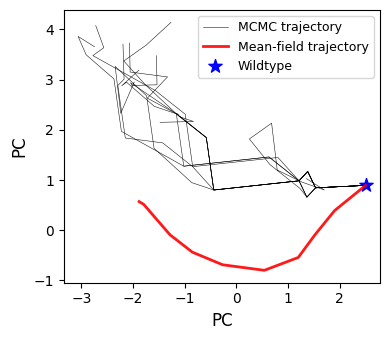

In [9]:
def project_and_plot_2d():


    # --- Load MCMC paths ---

    # --- Project reference points and trajectories ---

    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, svd_solver="full", random_state=0)
    pca.fit(mopt)  # fit only on mean-field trajectory (excluding final point)
    print("explained variance ratio", pca.explained_variance_ratio_)
    mopt_2d = pca.transform(mopt)
    paths_mcmc_2d = pca.transform(paths_mcmc.reshape(-1, paths_mcmc.shape[2])).reshape(paths_mcmc.shape[0], paths_mcmc.shape[1], 2)
    #ranomly select 5 MCMC trajectories to plot
    import random
    random.seed(0)  # for reproducibility
    random_idxs = random.sample(range(len(paths_mcmc)), 10)
    print("random_idxs", random_idxs)
    paths_mcmc_2d = paths_mcmc_2d[random_idxs]


    wt_2d = paths_mcmc_2d[0]

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(4, 3.5))

    # Scatter of observed sequences


    # --- MCMC trajectories in thick black lines (only one label) ---
    for i, path in enumerate(paths_mcmc_2d):
        label = "MCMC trajectory" if i == 0 else None
        ax.plot(path[:, 0], path[:, 1],
                color='black', linewidth=0.4, alpha=0.9,
                label=label)
        
    #plot mopt2D
    ax.plot(mopt_2d[:,0], mopt_2d[:,1],
            color='red', linewidth=2, alpha=0.9,
            label="Mean-field trajectory")

    # --- VOC stars and annotations ---


    # --- Wildtype star ---
    ax.scatter(wt_2d[0, 0], wt_2d[0, 1], color='blue', marker='*', s=100, label='Wildtype')

    # --- Labels and colorbar ---
    ax.set_ylabel("PC", fontsize=12)
    ax.set_xlabel("PC", fontsize=12)



    ax.legend(loc='best', frameon=True, fontsize=9)

    # --- PRL-style black frame ---
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.show()

project_and_plot_2d()


random_idxs [49, 97, 53, 5, 33, 65, 62, 51, 38, 61]


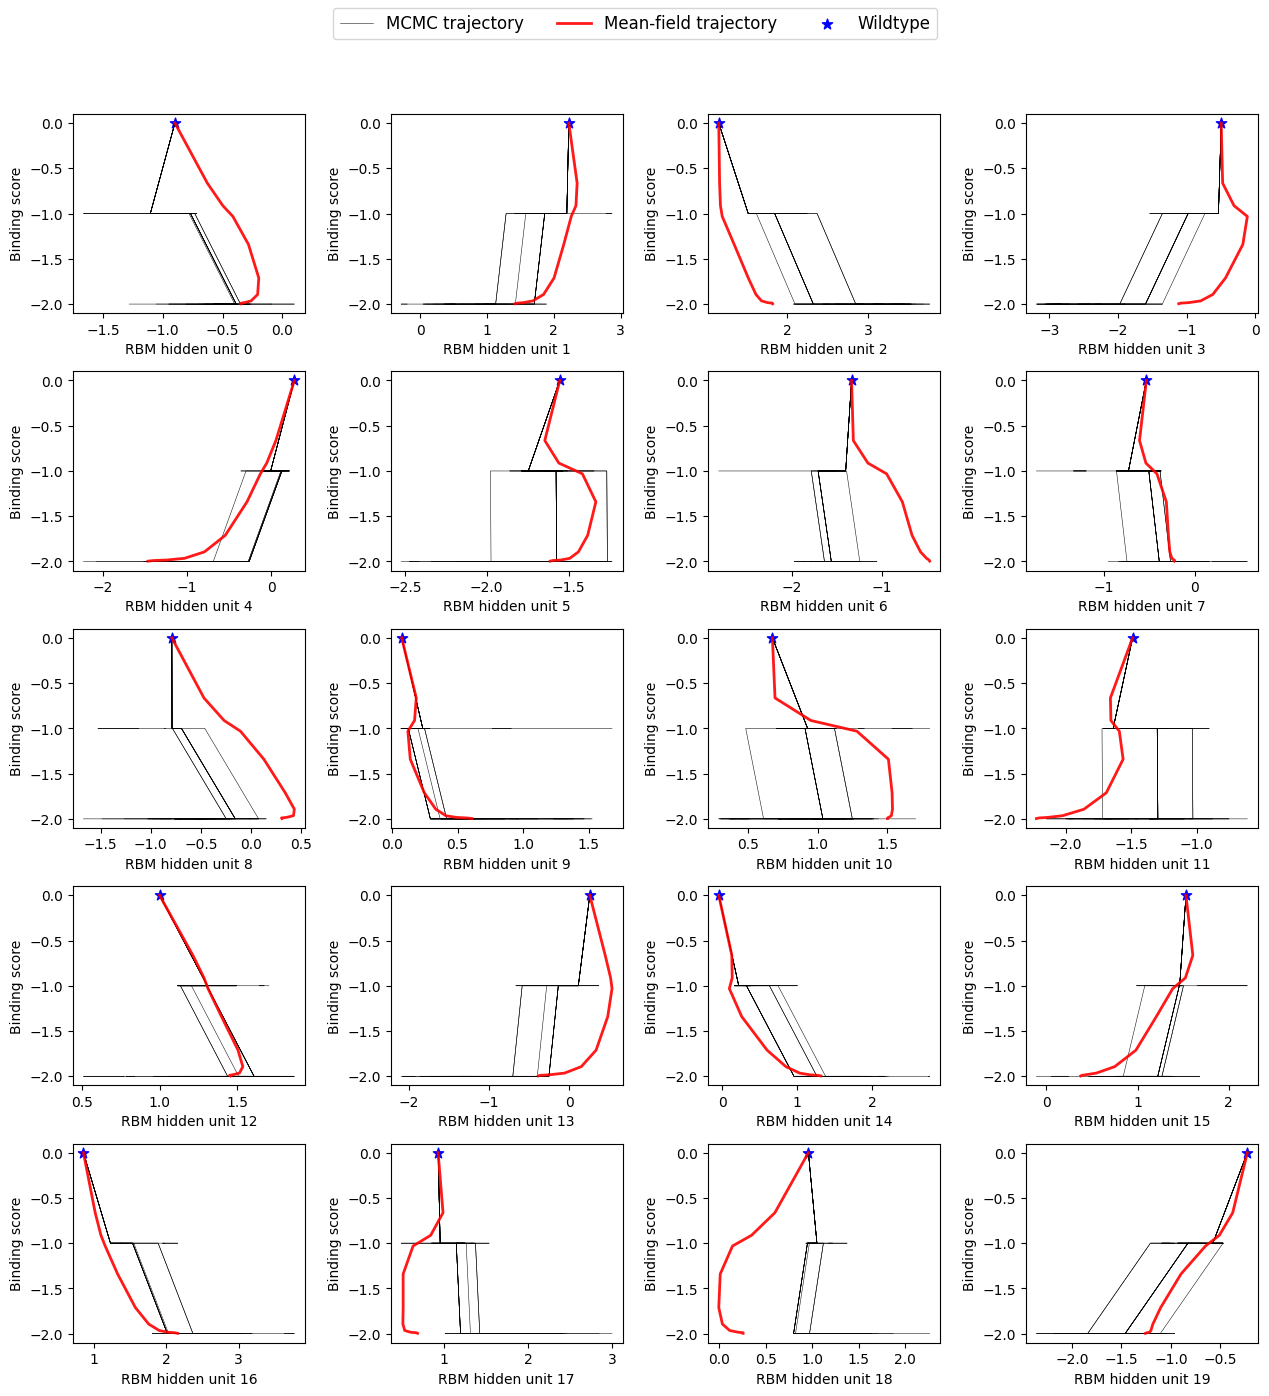

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

def project_and_plot_2d(n_random_paths=10, seed=0, ncols=4, js=None):
    """
    Plots subplots for each j in js:
      x-axis = coordinate j
      y-axis = last coordinate (index D-1)
    Expects global arrays:
      - mopt:          shape (T+1, D)
      - paths_mcmc:    shape (N_paths, T+1, D)
    """
    assert mopt.ndim == 2 and paths_mcmc.ndim == 3, "mopt (T,D), paths_mcmc (N,T,D)"
    T, D = mopt.shape
    last_idx = D - 1
    if js is None:
        js = [j for j in range(D) if j != last_idx]  # all except last

    # Randomly select MCMC trajectories to plot
    random.seed(seed)
    N = paths_mcmc.shape[0]
    n_pick = min(n_random_paths, N)
    random_idxs = random.sample(range(N), n_pick)
    print("random_idxs", random_idxs)

    # Use the first selected path's first point as "wildtype"
    wt = paths_mcmc[random_idxs[0], 0]  # shape (D,)

    # --- Layout ---
    nplots = len(js)
    nrows = math.ceil(nplots / ncols)
    figsize = (3.2 * ncols, 2.8 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    # For a single shared legend later
    handled_legend = False

    for k, j in enumerate(js):
        ax = axes[k]

        # MCMC trajectories (thin black)
        for i, pidx in enumerate(random_idxs):
            path = paths_mcmc[pidx]  # (T+1, D)
            lbl = "MCMC trajectory" if (i == 0 and not handled_legend) else None
            ax.plot(path[:, j], path[:, last_idx],
                    color='black', linewidth=0.4, alpha=0.9, label=lbl)

        # Mean-field trajectory (thick red)
        lbl = "Mean-field trajectory" if not handled_legend else None
        ax.plot(mopt[:, j], mopt[:, last_idx],
                color='red', linewidth=2, alpha=0.9, label=lbl)

        # Wildtype star (blue)
        lbl = "Wildtype" if not handled_legend else None
        ax.scatter(wt[j], wt[last_idx], color='blue', marker='*', s=60, label=lbl)

        ax.set_xlabel(f"RBM hidden unit {j}")
        ax.set_ylabel("Binding score")
        # ax.set_title(f"Unit {last_idx} vs Unit {j}", fontsize=9)

        # PRL-style black frame, no grid
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.8)

        if not handled_legend:
            handled_legend = True

    # Hide any unused axes
    for k in range(nplots, len(axes)):
        axes[k].axis('off')

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, fontsize=12)

    plt.tight_layout(rect=(0, 0, 1, 0.93))  # leave space for shared legend
    plt.show()

# Call it:
project_and_plot_2d()


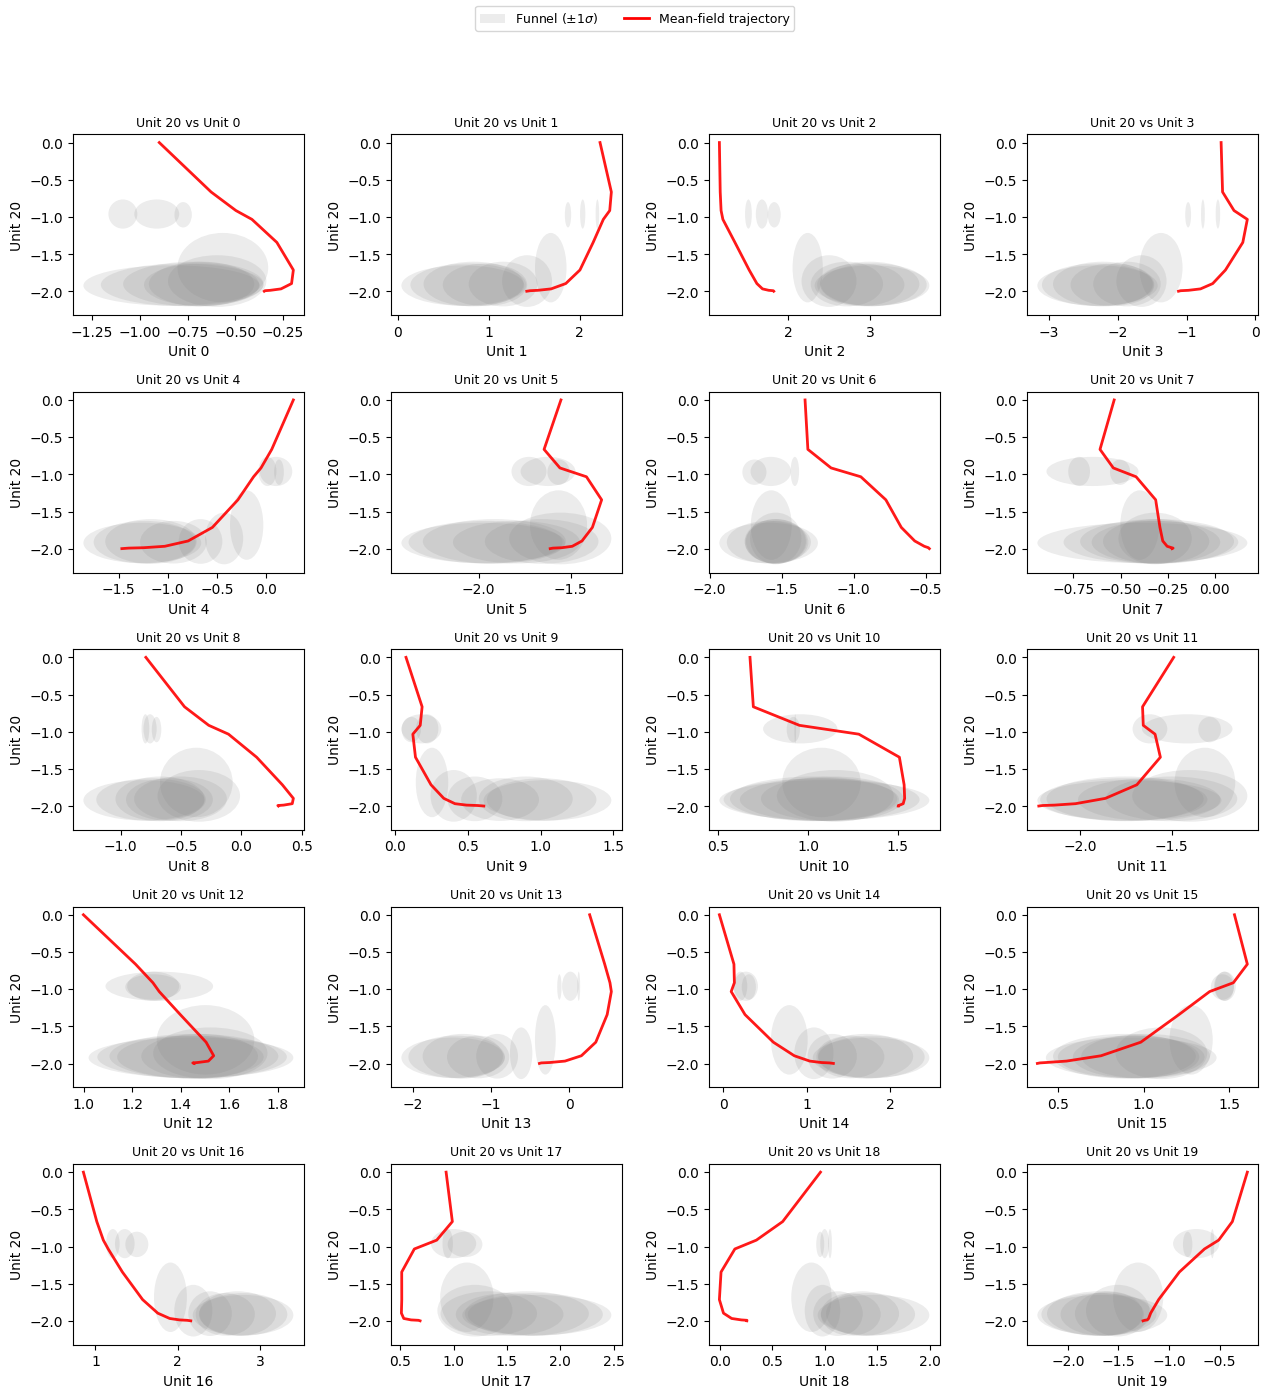

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Ellipse, Patch
from matplotlib.lines import Line2D

def plot_funnel_per_unit(ncols=4, js=None, step_stride=1, std_scale=1.0, ellipse_alpha=0.15):
    """
    For each unit j, plot (x_j, x_{D-1}) with:
      - Shaded axis-aligned ellipses per time step t representing ± std on x and y across MCMC paths
      - Mean-field trajectory (mopt) as a red line

    Expects:
      mopt:        (T+1, D)
      paths_mcmc:  (N_paths, T+1, D)

    Parameters:
      ncols:          grid columns
      js:             list of unit indices to plot on x-axis (default: all except D-1)
      step_stride:    plot every 'step_stride' time steps to reduce clutter
      std_scale:      multiply std by this factor (e.g., 2.0 for ±2σ)
      ellipse_alpha:  transparency of the funnel ellipses
    """
    assert mopt.ndim == 2 and paths_mcmc.ndim == 3, "mopt (T+1,D), paths_mcmc (N,T+1,D)"
    T1, D = mopt.shape
    last_idx = D - 1
    if js is None:
        js = [j for j in range(D) if j != last_idx]

    nplots = len(js)
    nrows = math.ceil(nplots / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.8*nrows), squeeze=False)
    axes = axes.ravel()

    for k, j in enumerate(js):
        ax = axes[k]

        # Funnel: one ellipse per time step
        for t in range(0, T1, step_stride):
            xs = paths_mcmc[:, t, j]
            ys = paths_mcmc[:, t, last_idx]
            mu_x = xs.mean()
            mu_y = ys.mean()
            std_x = xs.std(ddof=0)
            std_y = ys.std(ddof=0)

            e = Ellipse(
                (mu_x, mu_y),
                width=2 * std_scale * std_x,
                height=2 * std_scale * std_y,
                angle=0.0,
                facecolor="gray",
                edgecolor="none",
                alpha=ellipse_alpha,
                zorder=1,
            )
            ax.add_patch(e)

        # Mean-field trajectory
        ax.plot(
            mopt[:, j], mopt[:, last_idx],
            color="red", linewidth=2, alpha=0.9,
            label="Mean-field trajectory" if k == 0 else None,
            zorder=2,
        )

        ax.set_xlabel(f"Unit {j}")
        ax.set_ylabel(f"Unit {last_idx}")
        ax.set_title(f"Unit {last_idx} vs Unit {j}", fontsize=9)

        # PRL-style black frame
        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(0.8)

    # Hide any unused axes
    for k in range(nplots, len(axes)):
        axes[k].axis("off")

    # Shared legend (one entry for ellipses + mean-field line)
    proxy_ellipse = Patch(facecolor="gray", alpha=ellipse_alpha, label=r"Funnel ($\pm 1\sigma$)")
    proxy_line = Line2D([0], [0], color="red", lw=2, label="Mean-field trajectory")
    fig.legend([proxy_ellipse, proxy_line],
               [r"Funnel ($\pm 1\sigma$)", "Mean-field trajectory"],
               loc="upper center", ncol=2, frameon=True, fontsize=9)

    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

# Example:
plot_funnel_per_unit(ncols=4, js=None, step_stride=1, std_scale=1.0, ellipse_alpha=0.15)


random_idxs [17, 72, 97, 8, 32, 15, 63, 57, 60, 83, 48, 26, 12, 62, 3, 49, 55, 77, 98, 0]


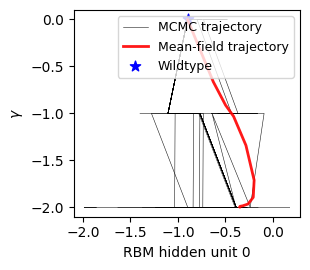

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import random

def project_and_plot_first_only(n_random_paths=20, seed=1, js=None):
    """
    Single-panel version of project_and_plot_2d:
      x-axis = coordinate j0 (first j in js or first non-last unit)
      y-axis = last coordinate (index D-1)
    Expects global arrays:
      - mopt:          shape (T+1, D)
      - paths_mcmc:    shape (N_paths, T+1, D)
    """
    assert mopt.ndim == 2 and paths_mcmc.ndim == 3, "mopt (T+1,D), paths_mcmc (N,T+1,D)"
    T1, D = mopt.shape
    last_idx = D - 1

    # default js: all except last; take the first one
    if js is None:
        js = [j for j in range(D) if j != last_idx]
    assert len(js) > 0, "No valid j to plot (D must be >= 2)."
    j0 = js[0]

    # Randomly select MCMC trajectories to plot
    random.seed(seed)
    N = paths_mcmc.shape[0]
    n_pick = min(n_random_paths, N)
    random_idxs = random.sample(range(N), n_pick)
    print("random_idxs", random_idxs)

    # Use the first selected path's first point as "wildtype"
    wt = paths_mcmc[random_idxs[0], 0]  # shape (D,)

    # --- Single panel ---
    fig, ax = plt.subplots(figsize=(3.2, 2.8))

    # MCMC trajectories (thin black)
    for i, pidx in enumerate(random_idxs):
        path = paths_mcmc[pidx]  # (T+1, D)
        lbl = "MCMC trajectory" if i == 0 else None
        ax.plot(path[:, j0], path[:, last_idx],
                color='black', linewidth=0.4, alpha=0.9, label=lbl)

    # Mean-field trajectory (thick red)
    ax.plot(mopt[:, j0], mopt[:, last_idx],
            color='red', linewidth=2, alpha=0.9, label="Mean-field trajectory")

    # Wildtype star (blue)
    ax.scatter(wt[j0], wt[last_idx], color='blue', marker='*', s=60, label='Wildtype')

    ax.set_xlabel(f"RBM hidden unit {j0}")
    ax.set_ylabel(r"$\gamma$")

    # PRL-style black frame, no grid
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    ax.legend(loc='best', frameon=True, fontsize=9)

    plt.tight_layout()
    plt.show()

# Call it:
project_and_plot_first_only()


In [13]:
idx

array([20,  4], dtype=int64)

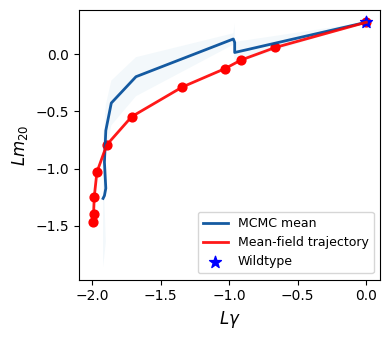

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def _make_band_polygon(xs_lower, ys_lower, xs_upper, ys_upper):
    """
    Build a closed polygon between two parametric curves:
      lower: (xs_lower[t], ys_lower[t])
      upper: (xs_upper[t], ys_upper[t])
    Curves are connected forward for lower and backward for upper.
    """
    pts_lower = np.column_stack([xs_lower, ys_lower])          # T x 2
    pts_upper = np.column_stack([xs_upper, ys_upper])[::-1, :] # T x 2 (reversed)
    pts = np.vstack([pts_lower, pts_upper])
    return Polygon(pts, closed=True, linewidth=0)

def project_and_plot_2d(*, band_alpha_xy=(0.18, 0.12),
                        band_color_x="#3182bd", band_color_y="#9ecae1",
                        mean_color="#08519c", mean_lw=2.0):
    """
    Plot 2D mean MCMC trajectory with shaded m±std ribbons
    (component-wise) and the provided mean-field trajectory mopt_2d.

    Expected globals:
        - paths_mcmc: list of arrays with shape (T, S), we use [:, idx] -> (T,2)
        - mopt_2d: array (T,2)
        - idx: tuple/list of two indices selecting the 2D projection
    """

    # ---- Stack MCMC trajectories to (N, T, 2) ----
    paths_mcmc_2d = [p[:, idx] for p in paths_mcmc]  # each: (T, 2)
    assert len(paths_mcmc_2d) > 0, "No MCMC paths."
    P = np.stack(paths_mcmc_2d, axis=0)              # (N, T, 2)
    N, T, _ = P.shape

    # ---- Mean and std per step ----
    mean_path = P.mean(axis=0)                       # (T, 2): [mx(t), my(t)]
    std_path  = P.std(axis=0, ddof=1 if N > 1 else 0)  # (T, 2): [sx(t), sy(t)]

    mx, my = mean_path[:, 0], mean_path[:, 1]
    sx, sy = std_path[:, 0],  std_path[:, 1]

    # ---- Build shaded ribbons (2D) ----
    # Vertical band: y in [my - sy, my + sy] at x = mx
    poly_y = _make_band_polygon(
        xs_lower=mx, ys_lower=my - sy,
        xs_upper=mx, ys_upper=my + sy
    )

    # Horizontal band: x in [mx - sx, mx + sx] at y = my
    poly_x = _make_band_polygon(
        xs_lower=mx - sx, ys_lower=my,
        xs_upper=mx + sx, ys_upper=my
    )

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(4, 3.5))

    # Add bands (draw y-band first, then x-band)
    poly_y.set_facecolor(band_color_y)
    poly_y.set_alpha(band_alpha_xy[1])
    ax.add_patch(poly_y)

    poly_x.set_facecolor(band_color_x)
    poly_x.set_alpha(band_alpha_xy[0])
    # ax.add_patch(poly_x)

    # Mean MCMC trajectory
    ax.plot(mx, my, color=mean_color, linewidth=mean_lw, alpha=0.95, label="MCMC mean")

    # Mean-field trajectory
    ax.plot(mopt_2d[:, 0], mopt_2d[:, 1],
            color='red', linewidth=2.0, alpha=0.9,
            label="Mean-field trajectory")
    ax.scatter(mopt_2d[:, 0], mopt_2d[:, 1], color='red', marker='o', s=40)  # start

    # Wildtype star (first step of first path)
    wt_2d = P[0, 0, :]
    ax.scatter(wt_2d[0], wt_2d[1], color='blue', marker='*', s=80, label='Wildtype')

    # Labels
    ax.set_ylabel(r"$L m_{" + str(idx[0]) + "}$", fontsize=12)
    ax.set_xlabel(r"$L \gamma$", fontsize=12)

    # Legend
    ax.legend(loc='best', frameon=True, fontsize=9)

    # PRL-style black frame, no grid
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.show()

project_and_plot_2d()


In [15]:
idx

array([20,  4], dtype=int64)

In [16]:
path_proba = '../mean_field_theory/results_scripts/lattice/mean_f_lattice_D_1_beta_ab_10.npy'
probas = np.load(path_proba)  # shape: (amino_acid, step, site)
#round to cloestes 10^4
probas = np.round(probas, 6)  # Round to 4 decimal places
probas.shape#Q,T,L
# check is at a given stgep, 2 non wt aa have prba above TH. WT is first seq of step T=0
probas

array([[[0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
         0.00000e+00, 0.00000e+00],
        [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
         0.00000e+00, 0.00000e+00],
        [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
         0.00000e+00, 0.00000e+00],
        ...,
        [6.00000e-06, 4.00000e-06, 2.10000e-04, ..., 0.00000e+00,
         0.00000e+00, 0.00000e+00],
        [1.56000e-04, 1.11000e-04, 6.60000e-04, ..., 0.00000e+00,
         0.00000e+00, 0.00000e+00],
        [1.27600e-03, 1.04800e-03, 1.21900e-03, ..., 0.00000e+00,
         5.00000e-06, 0.00000e+00]],

       [[0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 0.00000e+00,
         0.00000e+00, 0.00000e+00],
        [0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 0.00000e+00,
         0.00000e+00, 0.00000e+00],
        [0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 0.00000e+00,
         0.00000e+00, 0.00000e+00],
        ...,
        [0.00000e+00, 9.99951e-01, 1.23888e-01, ..., 3

In [17]:
import numpy as np
import os

def analyze_probabilities(path_proba=path_proba, threshold=0.1):
    # --- 1. Load Data ---
    if path_proba and os.path.exists(path_proba):
        print(f"Loading data from {path_proba}...")
        probas = np.load(path_proba)
    
    # Rounding as requested
    probas = np.round(probas, 6)
    Q, T, L = probas.shape
    print(f"Data Shape: Q={Q}, T={T}, L={L}")

    # --- 2. Define Wild Type (WT) ---
    # WT is defined as the amino acid with max probability at step T=0 for each site
    # shape: (L,) containing the index of the WT amino acid for each site
    wt_sequence = np.argmax(probas[:, 0, :], axis=0)
    print(f"WT Sequence (Indices): {wt_sequence}")

    # --- 3. The Check ---
    # "Check if at a given step, 2 non wt aa have proba above TH"
    
    print(f"\n--- Scanning for Multi-Mutant signatures (TH={threshold}) ---")
    
    detected_steps = []
    
    for t in range(T):
        # We want to count how many non-WT amino acids have P > TH at this step
        
        # Create a boolean mask for Prob > Threshold
        # Shape: (Q, L)
        above_th_mask = probas[:, t, :] > threshold
        
        # We need to exclude the WT amino acid from this count.
        # We can set the mask to False at the WT indices.
        for l in range(L):
            wt_aa = wt_sequence[l]
            above_th_mask[wt_aa, l] = False
            
        # Now, above_th_mask only contains True for NON-WT amino acids > TH
        
        # METRIC 1: Check for multiple non-WT variants AT THE SAME SITE
        # Sum over Q (dim 0) to see how many non-WT variants exist per site
        concurrent_mutants_per_site = np.sum(above_th_mask, axis=0) # Shape (L,)
        
        # Identify sites with >= 2 non-WT variants
        bifurcating_sites = np.where(concurrent_mutants_per_site >= 2)[0]
        
        if len(bifurcating_sites) > 0:
            detected_steps.append(t)
            print(f"[Step {t}] FOUND condition!")
            for l in bifurcating_sites:
                # Get the indices of the amino acids that triggered this
                mutant_indices = np.where(above_th_mask[:, l])[0]
                mutant_probs = probas[mutant_indices, t, l]
                wt_idx = wt_sequence[l]
                wt_prob = probas[wt_idx, t, l]
                
                print(f"  -> Site {l}: WT(aa={wt_idx}) p={wt_prob:.4f}")
                print(f"     Competing Non-WTs: {list(zip(mutant_indices, mutant_probs))}")

    if not detected_steps:
        print("No steps found where a site has >= 2 non-WT amino acids above threshold.")

    return probas

# --- Run Script ---
if __name__ == "__main__":
    # Replace with your actual path if running locally
    
    # Set Threshold (e.g., 0.1 or 0.05)
    analyze_probabilities(path_proba, threshold=0.1)

Loading data from ../mean_field_theory/results_scripts/lattice/mean_f_lattice_D_1_beta_ab_10.npy...
Data Shape: Q=20, T=11, L=27
WT Sequence (Indices): [ 8  1  1  1  1  3  5 17  2  3 19 13  5  1  9 12  8 17  6  1  9  7  1  2
  8  8  9]

--- Scanning for Multi-Mutant signatures (TH=0.1) ---
[Step 6] FOUND condition!
  -> Site 4: WT(aa=1) p=0.4206
     Competing Non-WTs: [(4, 0.210958), (10, 0.274963)]
[Step 7] FOUND condition!
  -> Site 2: WT(aa=1) p=0.3484
     Competing Non-WTs: [(2, 0.48399), (3, 0.166709)]
  -> Site 4: WT(aa=1) p=0.1686
     Competing Non-WTs: [(4, 0.303158), (7, 0.117779), (10, 0.386029)]
[Step 8] FOUND condition!
  -> Site 2: WT(aa=1) p=0.1239
     Competing Non-WTs: [(2, 0.636202), (3, 0.236437)]
  -> Site 4: WT(aa=1) p=0.0393
     Competing Non-WTs: [(4, 0.349228), (7, 0.141081), (10, 0.438857)]
[Step 9] FOUND condition!
  -> Site 2: WT(aa=1) p=0.0475
     Competing Non-WTs: [(2, 0.681296), (3, 0.262994)]
  -> Site 4: WT(aa=1) p=0.0079
     Competing Non-WTs: [(

In [18]:
import numpy as np

probas=np.load(path_proba)  # shape: (amino_acid, step, site)
# (1) Ensure each (step, site) column is a valid distribution
probas = probas / probas.sum(axis=0, keepdims=True)


C:\Users\maria\AppData\Local\Temp\ipykernel_21792\4116176787.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


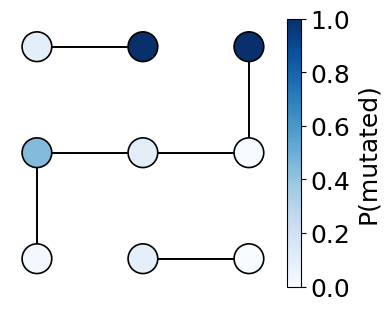

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable

# ───────────────────────────  ALPHABET  ─────────────────────────── #
CODE_RBM = [
    "A", "C", "D", "E", "F", "G", "H", "I", "K", "L",
    "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y",
]
aa_to_idx = {a:i for i,a in enumerate(CODE_RBM)}

# ───────────────────────────  LATTICE GEOMETRY  ─────────────────── #
LATTICE = {
    25: (0,  0), 26: (1,  0),  9: (2,  0),
    12: (0, -1), 11: (1, -1), 10: (2, -1),
    13: (0, -2), 16: (1, -2), 17: (2, -2),
}
BONDS = [
    (25, 26),          # top row
    (12, 11), (11, 10),
    (16, 17),
    (12, 13),          # left column
    (9, 10),           # vertical 9 ↔ 10
]
EPITOPE_SITES = list(LATTICE.keys())
sites_idx = np.array(EPITOPE_SITES) - 1  # convert 1-based to 0-based

# ─────────────────  MUTATION PROBABILITY PER (step, site)  ──────────────── #
def mutation_probabilities(
    probas: np.ndarray,                # shape (A, T, S)
    wt_letters: dict[int, str] | None = None  # optional: {site(1-based): 'A', ...}
) -> np.ndarray:
    """
    Returns P(mutated) with shape (T, S):
    mutated means amino acid != reference aa at the first step.
    Reference aa per site:
      - if wt_letters provided, use it
      - else: argmax over amino acids at step 0
    """
    # normalize over amino acids
    denom = probas.sum(axis=0, keepdims=True)    # (1, T, S)
    denom = np.where(denom == 0.0, 1.0, denom)
    p = probas / denom                           # (A, T, S)

    A, T, S = p.shape

    # Build reference index per site (length S)
    ref_idx = np.empty(S, dtype=int)

    if wt_letters is not None:
        # wt_letters keyed by 1-based site index
        for s0 in range(S):
            site_1b = s0 + 1
            if site_1b in wt_letters:
                ref_idx[s0] = aa_to_idx[wt_letters[site_1b]]
            else:
                # fallback to most probable at step 0 if missing
                ref_idx[s0] = int(np.argmax(p[:, 0, s0]))
    else:
        ref_idx = np.argmax(p[:, 0, :], axis=0)  # (S,)

    # P(mutated) = 1 - P(reference aa)
    # gather p_ref[t, s] = p[ref_idx[s], t, s]
    row = ref_idx[np.newaxis, :]                 # (1, S)
    col = np.arange(S)[np.newaxis, :]            # (1, S)
    # for each t, pick p[row, t, col]
    p_ref = p[row, np.arange(T)[:, None], col]   # (T, S)
    p_mut = 1.0 - p_ref
    return p_mut

# ─────────────────────────────  DRAWING  ─────────────────────────── #
def draw_epitope_scalar(
    ax,
    centre=(0.0, 0.0),
    value_map=None,          # dict {site:int -> float} for 9 sites
    edge_colour="black",
    scale=0.35,
    radius=0.14,
    z=3,
    cmap_name="Blues",
    norm=None
):
    """
    Draw 3×3 epitope: bonds + circles colored by provided scalar (no letters).
    """
    cx, cy = centre
    cmap = get_cmap(cmap_name)
    if norm is None:
        vmax = max(value_map.values()) if value_map else 1.0
        norm = Normalize(vmin=0.0, vmax=vmax)

    # bonds
    for a, b in BONDS:
        xa, ya = LATTICE[a]
        xb, yb = LATTICE[b]
        ax.plot(
            [cx + scale*xa, cx + scale*xb],
            [cy + scale*ya, cy + scale*yb],
            lw=1.4, color=edge_colour, zorder=z
        )

    # circles
    for site, (dx, dy) in LATTICE.items():
        v = value_map.get(site, 0.0)
        face = cmap(norm(v))
        circ = Circle(
            (cx + scale*dx, cy + scale*dy),
            radius*scale,
            facecolor=face,
            edgecolor=edge_colour,
            lw=1.2,
            zorder=z+1
        )
        ax.add_patch(circ)

    return norm, cmap

# ─────────────────────────  HIGH-LEVEL PLOTTER  ──────────────────────── #
def plot_epitope_pmut(
    probas: np.ndarray,            # (A, T, S)
    step: int,
    wt_letters: dict[int, str] | None = None,  # optional reference
    cmap_name: str = "Blues"
    #
):
    """
    Plot epitope colored by P(mutated) at a given step.
    If wt_letters is None, reference aa at each site is argmax at step 0.
    """
    p_mut = mutation_probabilities(probas, wt_letters=wt_letters)  # (T, S)

    # restrict to epitope sites
    vals = p_mut[step, sites_idx]                 # shape (9,)
    value_map = {site: v for site, v in zip(EPITOPE_SITES, vals)}

    # figure
    fig, ax = plt.subplots(figsize=(4, 4))
    norm = Normalize(vmin=0.0, vmax=1.0)         # probability in [0, 1]
    norm, cmap = draw_epitope_scalar(
        ax,
        centre=(0.0, 0.0),
        value_map=value_map,
        edge_colour="black",
        scale=0.35,
        radius=0.14,
        z=3,
        cmap_name=cmap_name,
        norm=norm
    )

    # colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("P(mutated)", fontsize=18)
    cbar.ax.tick_params(labelsize=18)           # bigger tick numbers
    ax.set_aspect("equal")
    ax.axis("off")
    # ax.set_title("Mean field")

    plt.tight_layout()
    return fig, ax

# ─────────────────────────────  USAGE  ───────────────────────────── #
# probas = np.load(path_proba)  # shape: (A, T, S)
# Option 1: from most probable aa at step 0
fig, ax = plot_epitope_pmut(probas, step=-1)

# Option 2: provide explicit wild-type letters for sites (1-based indexing)
# wt = {25:"Y", 26:"L", 9:"F", 12:"S", 11:"T", 10:"Q", 13:"N", 16:"V", 17:"I"}
# fig, ax = plot_epitope_pmut(probas, step=5, wt_letters=wt)
# plt.show()


# Comparison with MCMC

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from tqdm import tqdm

# -------------------
# Utils & Config
# -------------------
paths_nb = 100
beta_lattice = 1000
beta_w = 10
dir_in = f"paths/w_upper_T10_beta_ab_{beta_w}/"

# Define Alphabet Mapping (Standard 20 AAs)
alphabet = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {aa: i for i, aa in enumerate(alphabet)}
idx_to_aa = {i: aa for i, aa in enumerate(alphabet)}
A_len = len(alphabet)

def seq_to_indices(seq):
    """Converts a string sequence to a numpy array of indices."""
    # Maps unknown chars to -1 or handles them safely (here assuming clean data)
    return np.array([aa_to_idx.get(s, 0) for s in seq], dtype=int)


# -------------------
# Collect Data
# -------------------
all_path_indices = [] # Stores sequence indices (T_path, S) for each path
wt_seq_str = None     # To store the global WT (step 0)

for path_no in tqdm(range(paths_nb), desc=f"Reading β_w={beta_w}"):
    fasta_file = os.path.join(dir_in, f"output_{path_no}.fasta")
    if not os.path.exists(fasta_file):
        continue

    seqs = list(SeqIO.parse(fasta_file, "fasta"))
    if len(seqs) == 0:
        continue

    # Capture WT from the very first valid path
    if wt_seq_str is None:
        wt_seq_str = str(seqs[0].seq)

    # Convert all sequences in this path to integers
    # Shape: (T_steps, S_length)
    path_int_seqs = np.array([seq_to_indices(str(r.seq)) for r in seqs])
    
    all_path_indices.append(path_int_seqs)

if len(all_path_indices) == 0:
    raise RuntimeError("No valid paths loaded.")

# -------------------
# Align Dimensions
# -------------------
# 1. Determine common minimum T and common S
min_T = min(arr.shape[0] for arr in all_path_indices)
S_len = all_path_indices[0].shape[1]

print(f"Aggregating over {len(all_path_indices)} paths.")
print(f"Dimensions: A={A_len}, T={min_T}, S={S_len}")

# 2. Accumulate counts into tensor (A, T, S)
counts_tensor = np.zeros((A_len, min_T, S_len), dtype=np.float32)

for path_arr in all_path_indices:
    # Truncate to min_T
    # path_arr shape: (T_path, S) -> (min_T, S)
    truncated = path_arr[:min_T, :]
    
    # One-hot encoding trick to sum quickly
    # Create (min_T, S, A) one-hot
    # Note: Using np.eye is memory intensive if T*S is huge, 
    # but usually fine for protein simulations (e.g. 1000 steps * 200 sites).
    one_hot = np.eye(A_len)[truncated] # (min_T, S, A)
    
    # Transpose to (A, T, S) and add to accumulator
    counts_tensor += one_hot.transpose(2, 0, 1)
# -------------------
# -------------------
# Normalize to get probabilities
probas_mcmc = counts_tensor / counts_tensor.sum(axis=0, keepdims=True)




Reading β_w=10: 100%|██████████| 100/100 [00:00<00:00, 606.92it/s]

Aggregating over 100 paths.
Dimensions: A=20, T=11, S=27


C:\Users\maria\AppData\Local\Temp\ipykernel_21792\4116176787.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


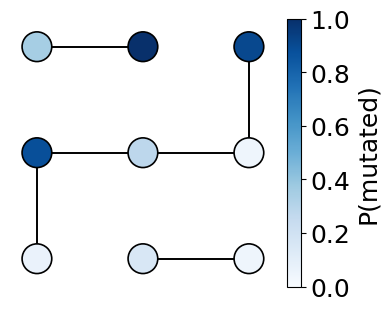

In [24]:
fig, ax = plot_epitope_pmut(probas_mcmc, step=-1)


In [25]:
mutation_probas_mcmc=mutation_probabilities(probas_mcmc)  # (T, S)
mutation_probabilities_mf=mutation_probabilities(probas)  # (T, S)





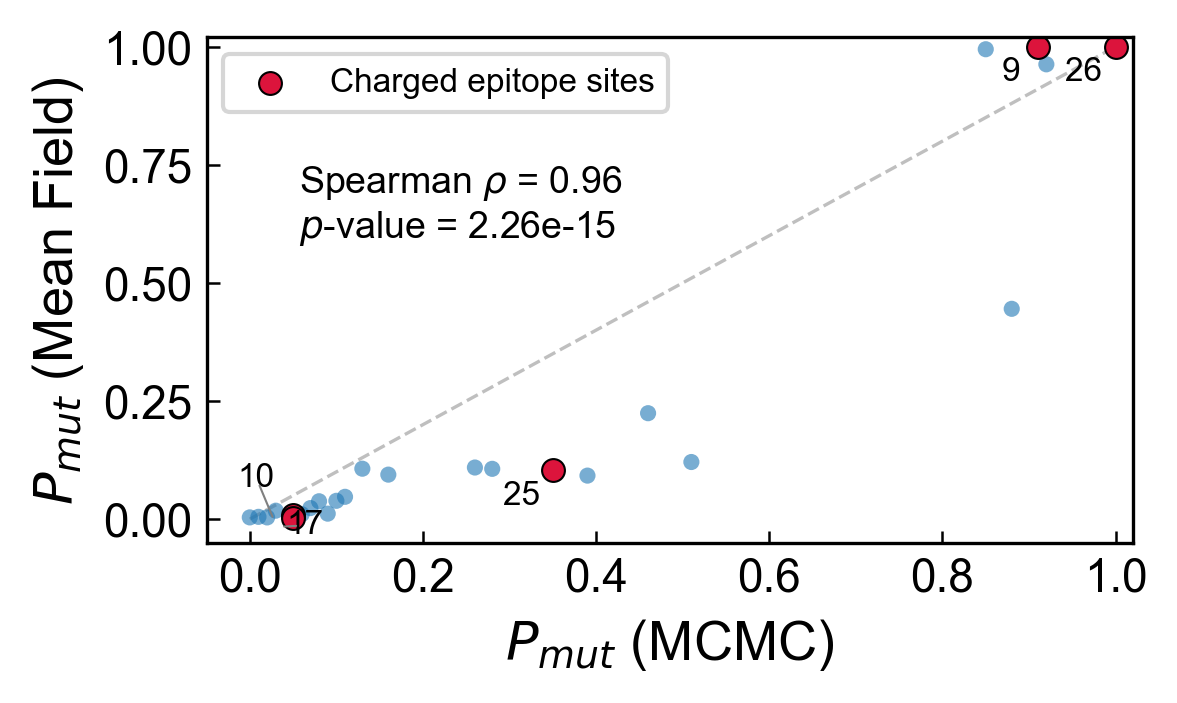

In [67]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.stats import spearmanr
from adjustText import adjust_text


# 1. Setup Data ------------------------------------------------
# Extract the data for the last time step (assuming shape is [steps, sites])
x_data = mutation_probas_mcmc[-1, :]
y_data = mutation_probabilities_mf[-1, :]

# Define the specific sites to highlight
# Note: Ensure these match Python's 0-based indexing. 
# If 15 is the 15th residue (starting at 1), change to 14.
target_indices = np.array([25, 26, 9,10,17] )-1

# Create an array of all indices to create a mask
# Create an array of all indices to create a mask
all_indices = np.arange(len(x_data))
mask_targets = np.isin(all_indices, target_indices)

# 2. Statistics ------------------------------------------------
rho, p_val = spearmanr(x_data, y_data)

# 3. Plotting --------------------------------------------------
fig, ax = plt.subplots(figsize=(4, 2.5), dpi=300)

# Plot 'Other' sites (Gray or Blue, sent to back with zorder)
ax.scatter(
    x_data[~mask_targets], 
    y_data[~mask_targets], 
    color='tab:blue', 
    alpha=0.6, 
    s=15, 
    edgecolor='none',
    # label='Other sites',
    zorder=1
)

# Plot 'Charge/Epitope' sites (Red, slightly larger, on top)

# 1. Plot the highlight points
ax.scatter(
    x_data[mask_targets], 
    y_data[mask_targets], 
    color='crimson', 
    alpha=1.0, 
    s=30, 
    edgecolor='black', 
    linewidth=0.5,
    label='Charged epitope sites', 
    zorder=2,
)

# 2. Create a list to store text objects
texts = []

for i in target_indices:
    texts.append(ax.text(
        x_data[i]-0.02, 
        y_data[i]-0.02, 
        str(i+1), # Keeping your 1-based labeling logic
        fontsize=8,
        color='black',
        ha='center',
        va='center'
    ))

# 3. Automatically adjust positions to avoid overlap
# arrowprops draws a line if the label is moved far away
adjust_text(
    texts, 
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_points=(1.2, 1.4),
    force_points=(0.2, 0.4),
    force_text=(0.2, 0.4),
    lim=1000
)


# Optional: Add a 1:1 diagonal line for reference
# ax.plot([0, 1], [0, 1], ls='--', c='gray', lw=0.8, alpha=0.5, zorder=0)

# 4. Styling & Labels ------------------------------------------
# Labels (Corrected from 'Step' to reflect Method vs Method comparison)
ax.set_xlabel(r"$P_{mut}$ (MCMC)")
ax.set_ylabel(r"$P_{mut}$ (Mean Field)")

# Display Spearman Correlation on plot
# write spearman and pval
ax.text(
    0.1, 0.75, 
    f"Spearman $\\rho$ = {rho:.2f}\n$p$-value = {p_val:.2e}",
    transform=ax.transAxes, 
    fontsize=9, 
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none')
)

# Apply your custom spine formatting
for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('black')
    s.set_linewidth(0.8)
#add y=x
ax.plot([0, 1], [0, 1], ls='--', c='gray', lw=0.8, alpha=0.5, zorder=0)

# Apply your custom tick formatting
ax.tick_params(direction='in', length=3, width=0.6)

# Legend (loc='lower right' is usually best for scatter plots to avoid covering data)
ax.legend(frameon=True, loc='upper left', fontsize=8)
#x ylim
ax.set_xlim(-0.05, 1.02)
ax.set_ylim(-0.05, 1.02)

plt.tight_layout()
plt.show()

# Escape as a function of time

In [47]:
POS_CHARGE = {"K", "R", "H"}
NEG_CHARGE = {"D", "E"}

sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
w = np.zeros((PROTEIN_INIT.shape[0] * 20))

for site in sites:
    wt_idx = PROTEIN_INIT[site]  # Integer index of WT amino acid
    wt_char = CODE_RBM[wt_idx]  # Character (e.g., 'K')

    for i in range(20):
        mut_char = CODE_RBM[i]  # Character of the mutation

        # Determine charge status
        wt_is_pos = wt_char in POS_CHARGE
        wt_is_neg = wt_char in NEG_CHARGE
        mut_is_pos = mut_char in POS_CHARGE
        mut_is_neg = mut_char in NEG_CHARGE

        # Logic: WT is (+) and Mut is (-) OR WT is (-) and Mut is (+)
        is_charge_flip = (wt_is_pos and mut_is_neg) or (wt_is_neg and mut_is_pos)

        # Check if mutation exists and if it is a charge flip
        if i != wt_idx and is_charge_flip:
            print(site)
            w[site * 20 + i] = 1

8
8
8
9
9
9
16
16
24
24
25
25


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from tqdm import tqdm
import matplotlib.ticker as mticker

# -------------------
# Config
# -------------------
paths_nb = 100
beta_w = 10  # only this one
dir_in = f"paths/w_upper_T10_beta_ab_{beta_w}/"

# Plot style (similar to consensus epitope plots)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 12,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300
})

# -------------------
# Collect paths
# -------------------
all_ll_biased_rbm   = []  # epitope Hamming distance per path

for path_no in tqdm(range(paths_nb), desc=f"Reading β_w={beta_w}"):
    fasta_file = os.path.join(dir_in, f"output_{path_no}.fasta")
    if not os.path.exists(fasta_file):
        continue

    seqs = list(SeqIO.parse(fasta_file, "fasta"))
    if len(seqs) == 0:
        continue

    wt_seq = str(seqs[0].seq)
    ll_customed = []
    ll_biased   = []

    for record in seqs:
        seq = str(record.seq)
        # Epitope Hamming distance to WT
        # epitope_overlap = sum(seq[j] != wt_seq[j] for j in epitope_sites)
        seq_num=Proteins_utils.seq2num(seq)[0]
        seq_num_one_hot=one_hot_encode_concat(seq_num)
        epitope_overlap=np.dot(seq_num_one_hot, w)
     

        # Your original transform:
        #   ll_c = (pnat - epitope_overlap * beta_w) / beta_lattice
        #   Pnat-like value = exp(ll_c)

        # Store epitope Hamming
        ll_biased.append(epitope_overlap)


    all_ll_biased_rbm.append(np.array(ll_biased))



all_ll_biased_rbm=np.array(all_ll_biased_rbm)  # shape: (N_paths, T_steps)
print("all_ll_biased_rbm shape:", all_ll_biased_rbm.shape)#n paths, T_steps


Reading β_w=10: 100%|██████████| 100/100 [00:00<00:00, 1068.63it/s]

all_ll_biased_rbm shape: (100, 11)


In [ ]:
print("all_ll_biased_rbm shape:", all_ll_biased_rbm.shape)#n paths, T_steps
gamma=np.load(f"../mean_field_theory/results_scripts/lattice/mean_f_lattice_D_1_beta_ab_{beta_w}"+"/mopt.npy")[:,-1]  # shape: (T_steps, D)
gamma.shape# T_stepes

all_ll_biased_rbm shape: (100, 11)


(11,)

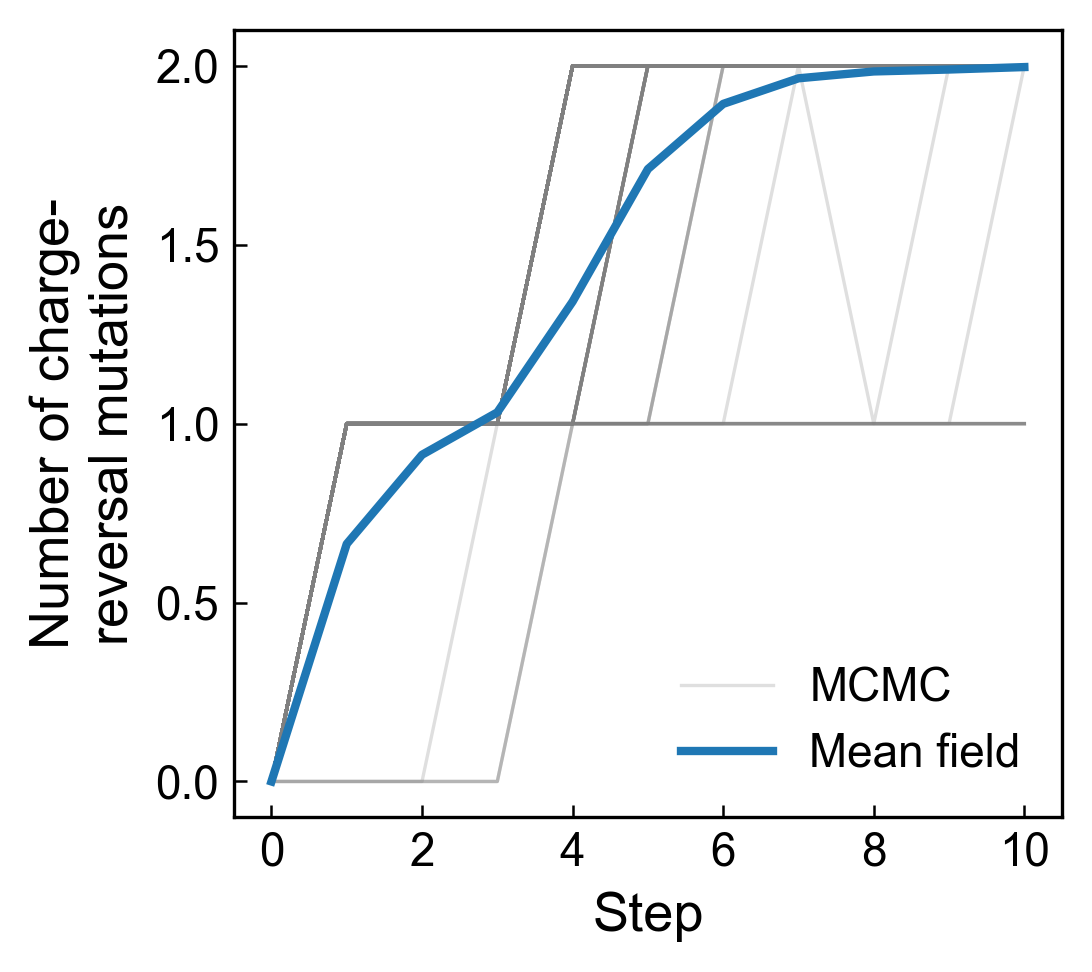

In [68]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# -------------------
# Figure: Individual RBM paths vs Mean Field Gamma
# -------------------
fig, ax = plt.subplots(figsize=(3.8, 3.4))

# Define x-axis (steps) based on the shape of the data
steps = np.arange(gamma.shape[0])

# 1. Plot individual RBM paths (Grey)
# Iterating over the first dimension (n_paths)
for i,arr in enumerate(all_ll_biased_rbm):
    if i==0:
        ax.plot(steps, arr, label="MCMC", color='gray', alpha=0.25, lw=0.8)
    else:
        ax.plot(steps, arr, color='gray', alpha=0.25, lw=0.8)

# 2. Plot Mean Field Gamma (Blue)
# Assuming gamma is 1D array of shape (T_steps,)
ax.plot(steps, gamma, label="Mean field", lw=2, color='tab:blue')

# 3. Labels and Limits
ax.set_xlabel("Step")
ax.set_ylabel("Number of charge-\nreversal mutations") # Replace 'Value' with appropriate physical quantity if known
# ax.xaxis.set_major_locator(mticker.MultipleLocator(2)) # Uncomment if you need specific tick spacing

# 4. Styling (Full black frame, inward ticks)
for s in ax.spines.values():
    s.set_visible(True)
    s.set_color('black')
    s.set_linewidth(0.8)

ax.tick_params(direction='in', length=3, width=0.6)

# 5. Legend and Layout
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()